In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df_lic = pd.read_parquet("data/data_licences/data_licences.parquet")
df_med = pd.read_csv("data/data_medailles/data_medailles_jo.csv")
df_or = pd.read_csv("data/data_medailles/data_or_jo.csv")

In [12]:
df_lic.head()

,code_2024,code_annee_n,codes_2016_2024,federation,annee,sexe,age,tranche_age,grande_tranche_age,region,departement_long,licences_annuelles,code_sport,code_dep
0,101,101,101,Fédération Française d'Athlétisme,2016,F,5,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,1,ATH,01
1,101,101,101,Fédération Française d'Athlétisme,2016,F,6,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,13,ATH,01
2,101,101,101,Fédération Française d'Athlétisme,2016,F,7,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,28,ATH,01
3,101,101,101,Fédération Française d'Athlétisme,2016,F,8,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,49,ATH,01
4,101,101,101,Fédération Française d'Athlétisme,2016,F,9,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,76,ATH,01


In [ ]:
def get_licences_par_annee(df_lic, sport_code=None, sport_col="code_sport"):
    df = df_lic.copy()

    if sport_code is not None:
        df = df[df[sport_col] == sport_code]

    res = (
        df.groupby("annee")["licences_annuelles"]
          .sum()
          .reset_index()
          .sort_values("annee")
    )

    if len(res) >= 2:
        res["variation"] = res["licences_annuelles"].diff()
        res["taux_evolution_%"] = res["licences_annuelles"].pct_change() * 100
    else:
        res["variation"] = np.nan
        res["taux_evolution_%"] = np.nan

    return res


def plot_licences_par_annee(df_lic, sport_code=None, sport_col="code_sport"):
    data = get_licences_par_annee(df_lic, sport_code, sport_col)

    plt.figure(figsize=(9, 5))
    plt.plot(data["annee"], data["licences_annuelles"], marker="o")
    titre = "Licences annuelles"
    if sport_code is not None:
        titre += f" - sport {sport_code}"
    plt.title(titre)
    plt.xlabel("Année")
    plt.ylabel("Licences annuelles")
    plt.grid(True)
    plt.tight_layout()
    plt.show()





def get_licences_par_sexe(df_lic, sport_code=None, sport_col="code_sport"):
    df = df_lic.copy()

    if sport_code is not None:
        df = df[df[sport_col] == sport_code]

    res = (
        df.groupby(["annee", "sexe"])["licences_annuelles"]
          .sum()
          .reset_index()
          .sort_values(["annee", "sexe"])
    )

    pivot = res.pivot(index="annee", columns="sexe", values="licences_annuelles")
    return res, pivot


def plot_licences_par_sexe(df_lic, sport_code=None, sport_col="code_sport"):
    _, pivot = get_licences_par_sexe(df_lic, sport_code, sport_col)

    plt.figure(figsize=(9, 5))
    for sexe in pivot.columns:
        plt.plot(pivot.index, pivot[sexe], marker="o", label=str(sexe))

    titre = "Licences annuelles par sexe"
    if sport_code is not None:
        titre += f" - sport {sport_code}"
    plt.title(titre)
    plt.xlabel("Année")
    plt.ylabel("Licences annuelles")
    plt.legend(title="Sexe")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#lic en dessous de age_max

def get_licences_jeunes(df_lic, age_max=15, sport_code=None, sport_col="code_sport"):
    df = df_lic.copy()

    if sport_code is not None:
        df = df[df[sport_col] == sport_code]

    total = (
        df.groupby("annee")["licences_annuelles"]
          .sum()
          .reset_index()
          .rename(columns={"licences_annuelles": "licences_total"})
    )

    jeunes = (
        df[df["age"] < age_max]
        .groupby("annee")["licences_annuelles"]
        .sum()
        .reset_index()
        .rename(columns={"licences_annuelles": "licences_jeunes"})
    )

    res = jeunes.merge(total, on="annee", how="left")
    res["part_jeunes_%"] = res["licences_jeunes"] / res["licences_total"] * 100

    return res


def plot_part_jeunes(df_lic, age_max=15, sport_code=None, sport_col="code_sport"):
    data = get_licences_jeunes(df_lic, age_max, sport_code, sport_col)

    plt.figure(figsize=(9, 5))
    plt.plot(data["annee"], data["part_jeunes_%"], marker="o")
    titre = f"Part des licenciés < {age_max} ans"
    if sport_code is not None:
        titre += f" - sport {sport_code}"
    plt.title(titre)
    plt.xlabel("Année")
    plt.ylabel("Part des jeunes (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


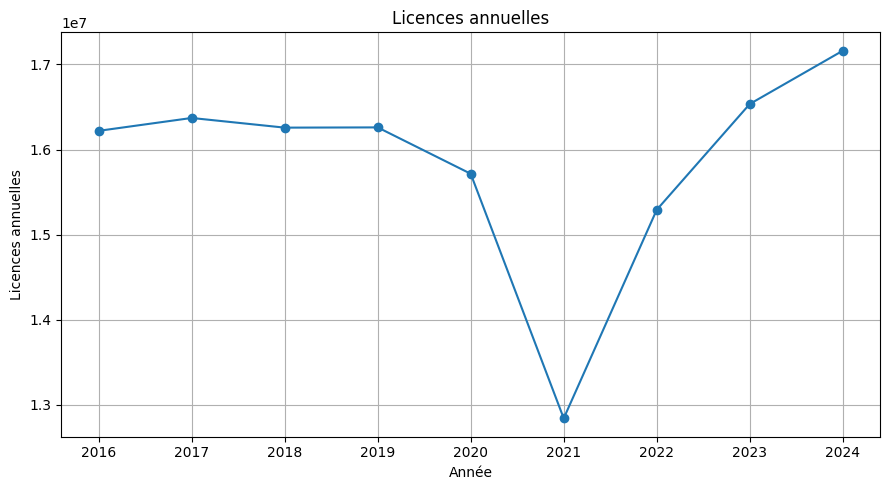

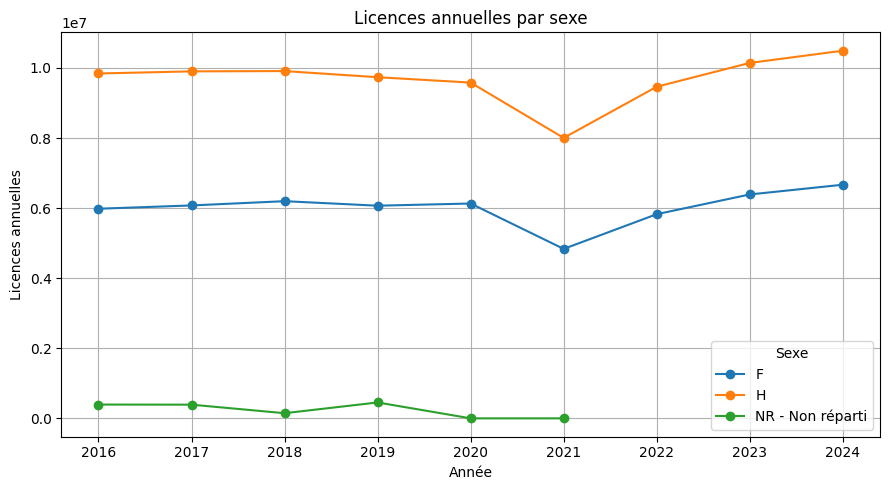

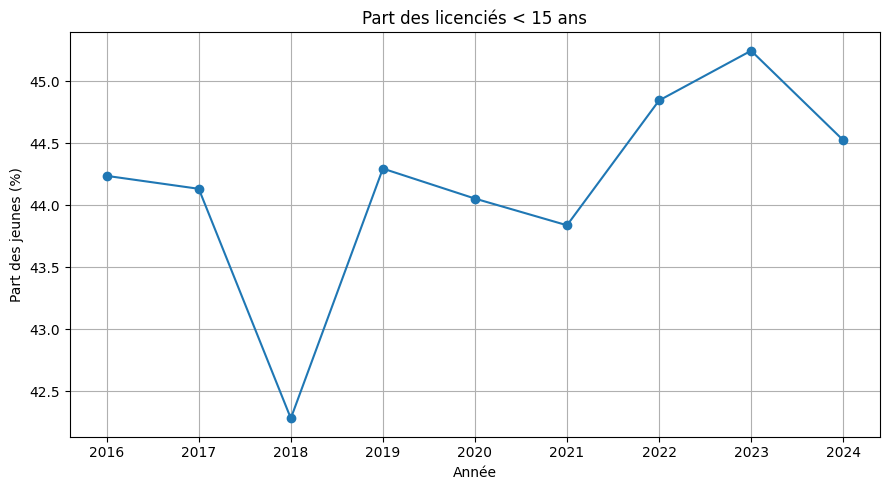

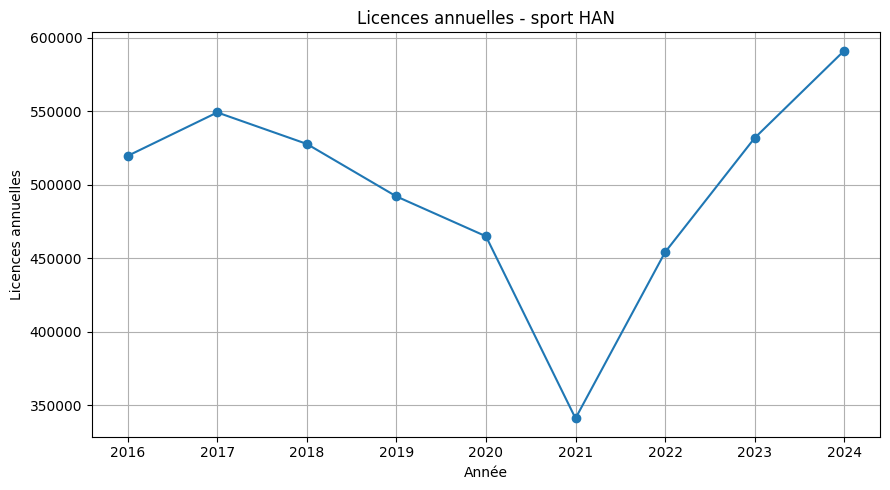

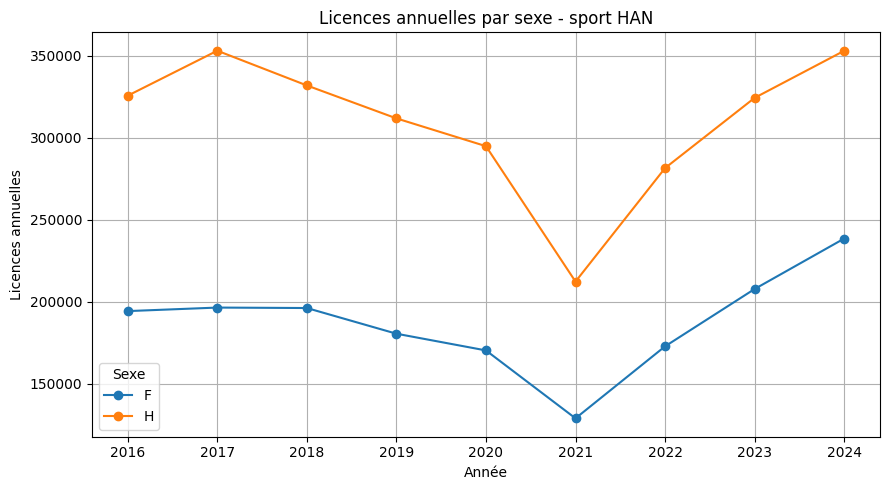

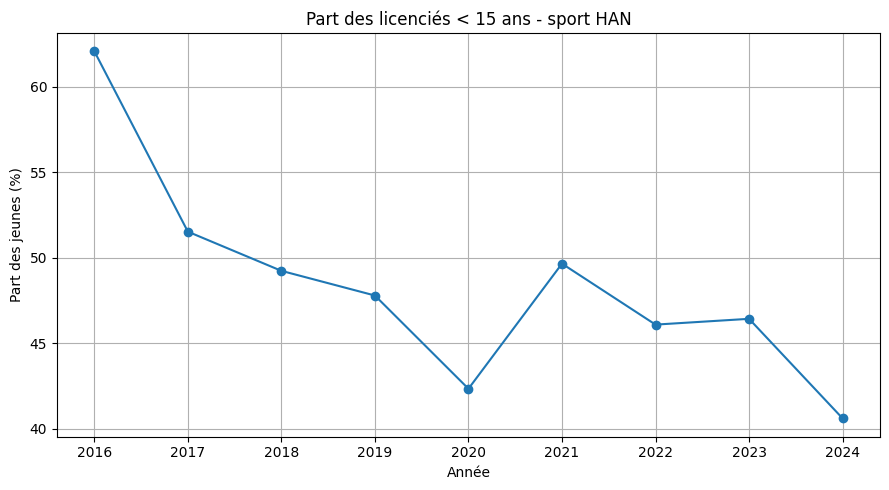

In [20]:
df_lic["age"] = pd.to_numeric(df_lic["age"], errors="coerce")

# global tous sports
plot_licences_par_annee(df_lic)
plot_licences_par_sexe(df_lic)
plot_part_jeunes(df_lic, age_max=15)

# uniquement Hand si ton code_sport du hand = "HAND"
plot_licences_par_annee(df_lic, sport_code="HAN")
plot_licences_par_sexe(df_lic, sport_code="HAN")
plot_part_jeunes(df_lic, age_max=15, sport_code="HAN")


In [33]:
def plot_hand_ratio_f_h(df_lic, sport_code="HAN", sport_col="code_sport"):
    df = df_lic.copy()
    df = df[df[sport_col] == sport_code]

    df_par_sexe = (
        df.groupby(["annee", "sexe"])["licences_annuelles"]
          .sum()
          .reset_index()
          .pivot(index="annee", columns="sexe", values="licences_annuelles")
    )

    df_par_sexe["ratio_f_h"] = df_par_sexe["F"] / df_par_sexe["H"]
    df_par_sexe.head()
    plt.figure(figsize=(10, 5))
    plt.plot(df_par_sexe.index, df_par_sexe["ratio_f_h"], marker="o")
    plt.title("Handball – Ratio Femmes / Hommes")
    plt.xlabel("Année")
    plt.ylabel("Ratio F / H")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [25]:
df_lic.head()

,code_2024,code_annee_n,codes_2016_2024,federation,annee,sexe,age,tranche_age,grande_tranche_age,region,departement_long,licences_annuelles,code_sport,code_dep
0,101,101,101,Fédération Française d'Athlétisme,2016,F,5.0,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,1,ATH,01
1,101,101,101,Fédération Française d'Athlétisme,2016,F,6.0,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,13,ATH,01
2,101,101,101,Fédération Française d'Athlétisme,2016,F,7.0,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,28,ATH,01
3,101,101,101,Fédération Française d'Athlétisme,2016,F,8.0,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,49,ATH,01
4,101,101,101,Fédération Française d'Athlétisme,2016,F,9.0,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,76,ATH,01


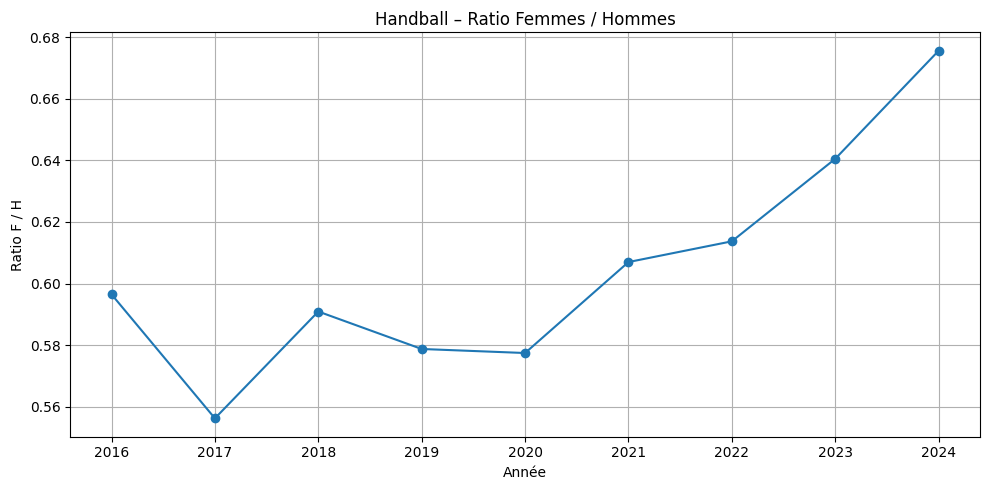

In [34]:
plot_hand_ratio_f_h(df_lic, sport_code="HAN", sport_col="code_sport")

In [35]:
import seaborn as sns

def plot_hand_heatmap(df_lic, sport_code="HAN", sport_col="code_sport"):
    df = df_lic.copy()
    df = df[df[sport_col] == sport_code]

    pivot = df.groupby(["annee", "tranche_age"])["licences_annuelles"] \
              .sum().reset_index().pivot(index="tranche_age", columns="annee", values="licences_annuelles")

    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot, cmap="Blues", annot=False)
    plt.title("Handball – Heatmap Licences (année × tranche d’âge)")
    plt.tight_layout()
    plt.show()


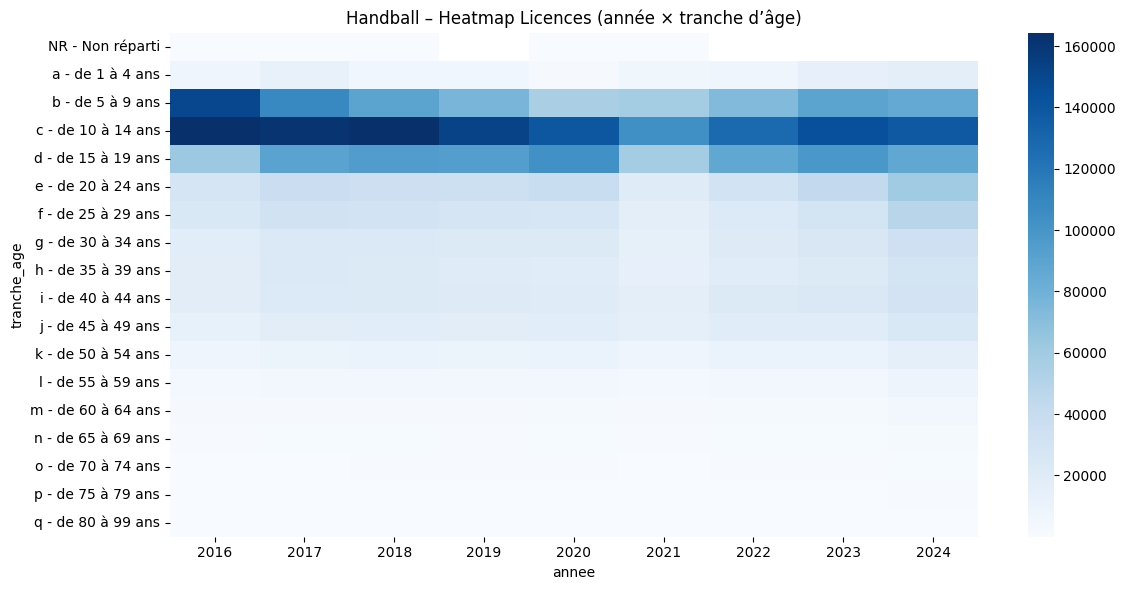

In [36]:
plot_hand_heatmap(df_lic, sport_code="HAN", sport_col="code_sport")

In [17]:
df_lic.columns

Index(['code_2024', 'code_annee_n', 'codes_2016_2024', 'federation', 'annee',
       'sexe', 'age', 'tranche_age', 'grande_tranche_age', 'region',
       'departement_long', 'licences_annuelles', 'code_sport', 'code_dep'],
      dtype='object')